In [1]:
# вычисление и визуализация напряженности
# магнитного поля и векторного потенциала
# соленоида с постоянным током
# в соответствие с (5.37), (5.39)

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


In [ ]:
# Ячейка № 2

# задание функции, возвращающей значения
# проекций напряженности магнитного поля
# на оси OX, OY, OZ, вычисляемые в соответствии с (5.37)


def Solenoid(x0, y0, z0, a, h, N):
    # x0, y0, z0 - координаты радиуса-вектора
    #              точки наблюдения
    # a - радиус окружности соленоида
    # h - шаг намотки проводника
    # N - число витков

    # задание числа элементов, используемых для
    # аппроксимации обмотки соленоида
    Nstep = 2000

    # вычисление координат узлов сетки по переменной phi
    phi = np.linspace(0, 2 * np.pi * N, Nstep)

    # инициализация массивов, используемых для
    # для хранения значений напряженности магнитного поля,
    # вычисляемого в соответствие с (5.37)
    s = np.zeros([Nstep, 3])

    # вычисление значения шага сетки по переменной phi
    delta_phi = phi[1] - phi[0]

    # вычисление значений напряженности магнитного поля
    # в узлах выбранной координатной сетки в соответствии с (5.37)
    s = [0, 0, 0]
    for n in range(Nstep):
        R = np.array([a * np.cos(phi[n]), a * np.sin(phi[n]), h * phi[n] / (2 * np.pi)])
        t = np.array([-a * np.sin(phi[n]), a * np.cos(phi[n]), h / (2 * np.pi)])

        # задание радиуса-вектора точки наблюдения
        R0 = np.array([x0, y0, z0])

        # вычисление координат радиуса-вектора R-r
        R1 = np.array([R0[0] - R[0], R0[1] - R[1], R0[2] - R[2]])

        # вычисление значений напряженности магнитного поля
        # в i,j-ом узле координатной сетки в соответствии в (5.37)
        s = s + np.cross(t, R1) / np.sqrt(np.dot(R1, R1)) ** 3

    # сохранение значений составляющих напряженностей
    # магнитного поля вдоль осей OX, OY, OZ
    bx = s[0] * delta_phi
    by = s[1] * delta_phi
    bz = s[2] * delta_phi

    return bx, by, bz

In [ ]:
# Ячейка № 3

# задание функции, возвращающей значения
# векторного потенциала магнитного поля
# на оси OX, OY, OZ, вычисляемые в соответствии с (5.39)
def SolenoidA(x0, y0, z0, a, h, N):
    # x0, y0, z0 - координаты радиуса-вектора
    #              точки наблюдения
    # a - радиус окружности соленоида
    # h - шаг намотки проводника
    # N - число витков

    # задание числа элементов, используемых для
    # аппроксимации намотки соленоида
    Nstep = 2000

    # вычисление координат узлов сетки по переменной phi
    phi = np.linspace(0, 2 * np.pi * N, Nstep)

    # инициализация массивов, используемых для
    # для хранения значений напряженности магнитного поля,
    # вычисляемого в соответствие с (5.37)
    s = np.zeros([Nstep, 3])

    # вычисление значения шага сетки по переменной phi
    delta_phi = phi[1] - phi[0]

    # вычисление значений напряженности магнитного поля
    # в узлах выбранной координатной сетки в соответствии с (5.39)
    s = [0, 0, 0]
    for n in range(Nstep):
        R = np.array([a * np.cos(phi[n]), a * np.sin(phi[n]), h * phi[n] / (2 * np.pi)])
        t = np.array([-a * np.sin(phi[n]), a * np.cos(phi[n]), h / (2 * np.pi)])

        # задание радиуса-вектора точки наблюдения
        R0 = np.array([x0, y0, z0])

        # вычисление координат радиуса-вектора R-r
        R1 = np.array([R0[0] - R[0], R0[1] - R[1], R0[2] - R[2]])

        # вычисление значений векторного потенциала магнитного поля
        # в i,j-ом узле координатной сетки в соответствии в (5.39)
        s = s + t / np.sqrt(np.dot(R1, R1))
    # сохранение значений составляющих напряженностей
    # вектора потенциала магнитного поля
    Ax = s[0] * delta_phi
    Ay = s[1] * delta_phi
    Az = s[2] * delta_phi

    return Ax, Ay, Az

In [4]:
# Ячейка № 4

# задание параметров соленоида

# радиус соленоида
a = 0.5

# длина соленоида
L = 3

# число витков провода соленоида
N = 100

# вычисление шага намотки соленоида
h = L / N

# задание числа узлов
# координатной сетки по оси OY
Ny = 27

# задание числа узлов
# координатной сетки по оси OZ
Nz = 27

# задание координат левого нижнего
# узла координатной сетки
Ymin = -5
Zmin = -3

# задание координат правого верхнего
# узла координатной сетки
Ymax = 5
Zmax = 6

# задание ординат узлов координатной сетки
Y = np.linspace(Ymin, Ymax, Ny)

# задание аппликат узлов координатной сетки
Z = np.linspace(Zmin, Zmax, Nz)

# создание матриц, используемых для визуализации
# векторного поля
[Y1, Z1] = np.meshgrid(Y, Z)
# инициализация массивов Bx, By, Bz, используемых
# для хранения значений составляющих напряженности
# магнитного поля соленоида вдоль координатных осей
Bx = np.zeros([Ny, Nz])
By = np.zeros([Ny, Nz])
Bz = np.zeros([Ny, Nz])
# вычисление значений составляющих напряженности
# магнитного поля соленоида вдоль координатных осей
for i in range(Ny):
    for j in range(Nz):
        bx, by, bz = Solenoid(0, Y1[i, j], Z1[i, j], a, h, N)
        Bx[i, j] = bx
        By[i, j] = by
        Bz[i, j] = bz

# вычисление модуля проекции напряженности
# на плоскость YOZ
mp = np.zeros([Ny, Nz])
for i in range(Ny):
    for j in range(Nz):
        mp[i, j] = np.sqrt(By[i, j] ** 2 + Bz[i, j] ** 2)

# инициализация массивов by1, bz1, используемых для
# для хранения значений координат единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
by1 = np.zeros([Ny, Nz])
bz1 = np.zeros([Ny, Nz])

# вычисление абсцисс и аппликат единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
for i in range(Ny):
    for j in range(Nz):
        by1[i, j] = By[i, j] / mp[i, j]
        bz1[i, j] = Bz[i, j] / mp[i, j]

# вычисление модуля векторного потенциала
# задание числа узлов координатной сетки,
# используемой для расчета и визуализации
# модуля векторного потенциала
Ny = 37
Nz = 37

# задание ординат узлов координатной сетки
Y2 = np.linspace(Ymin, Ymax, Ny)

# задание аппликат узлов координатной сетки
Z2 = np.linspace(Zmin, Zmax, Nz)

# создание матриц, используемых для визуализации
# векторного поля
[Y3, Z3] = np.meshgrid(Y2, Z2)

# инициализация матриц, используемых для
# сохранения значений проекций
# векторного потенциала на оси координат
Ax = np.zeros([Ny, Nz])
Ay = np.zeros([Ny, Nz])
Az = np.zeros([Ny, Nz])

# вычисление проекций векторного потенциала
# на оси координат в узлах выбранной
# координатной сетки в соответствие с (5.39)
for i in range(Ny):
    for j in range(Nz):
        ax, ay, az = SolenoidA(0, Y3[i, j], Z3[i, j], a, h, N)
        Ax[i, j] = ax
        Ay[i, j] = ay
        Az[i, j] = az

# инициализация матрицы, используемой для
# сохранения значений модуля
# векторного потенциала
A = np.zeros([Ny, Nz])

# вычисление модуля
# векторного потенциала
# в узлах выбранной координатной сетки
for i in range(Ny):
    for j in range(Nz):
        A[i, j] = np.sqrt(Ax[i, j] ** 2 + Ay[i, j] ** 2 + Az[i, j] ** 2)

In [5]:
# Ячейка № 5

# вычисление значений
# составляющих напряженностей
# магнитного поля соленоида в плоскости Z = 1.5
# задание параметров соленоида

# задание числа узлов координатной сетки
# осям OX, OY
Nx = 17
Ny = 17

# задание координат левого нижнего
# узла координатной сетки
Xmin = -5
Ymin = -5

# задание координат правого верхнего
# узла координатной сетки
Xmax = 5
Ymax = 5

# задание абсцисс узлов координатной сетки
X4 = np.linspace(Xmin, Xmax, Nx)

# задание ординат узлов координатной сетки
Y4 = np.linspace(Ymin, Ymax, Ny)

# создание матриц, используемых
# для визуализации векторного поля
[X5, Y5] = np.meshgrid(X4, Y4)

# инициализация массивов Bx, By, Bz, используемых
# для хранения значений составляющих напряженности
# магнитного поля соленоида вдоль координатных осей
Bx2 = np.zeros([Nx, Ny])
By2 = np.zeros([Nx, Ny])
Bz2 = np.zeros([Nx, Ny])

# вычисление значений составляющих напряженности
# магнитного поля соленоида вдоль осей OX, OY, OZ
# в плоскости Z = 1.5 в соответствие с (5.37)
for i in range(Nx):
    for j in range(Ny):
        bx2, by2, bz2 = Solenoid(X5[i, j], Y5[i, j], 1.5, a, h, N)
        Bx2[i, j] = bx2
        By2[i, j] = by2
        Bz2[i, j] = bz2

# вычисление модуля проекции напряженности
# на плоскость YOZ в соответствие с (5.37)
mp2 = np.zeros([Nx, Ny])
for i in range(Nx):
    for j in range(Ny):
        mp2[i, j] = np.sqrt(Bx2[i, j] ** 2 + By2[i, j] ** 2)

# инициализация массивов bx2_norm, by2_norm, используемых для
# для хранения значений координат единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
bx2_norm = np.zeros([Nx, Ny])
by2_norm = np.zeros([Nx, Ny])

# вычисление абсцисс и ординат единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
for i in range(Nx):
    for j in range(Ny):
        bx2_norm[i, j] = Bx2[i, j] / mp2[i, j]
        by2_norm[i, j] = By2[i, j] / mp2[i, j]

# вычисление модуля векторного потенциала

# задание числа узлов координатной сетки,
# используемой для расчета и визуализации
# модуля векторного потенциала
Nx = 37
Ny = 37

# задание абсцисс узлов координатной сетки
X6 = np.linspace(Xmin, Xmax, Nx)

# задание ординат узлов координатной сетки
Y6 = np.linspace(Ymin, Ymax, Ny)

# создание матриц, используемых
# для визуализации векторного поля
[X7, Y7] = np.meshgrid(X6, Y6)
# инициализация матриц, используемых для

# инициализация массивов Ax, Ay,Az,
# используемых для хранения значений
# проекций векторного потенциала
# на оси координат
Ax2 = np.zeros([Nx, Ny])
Ay2 = np.zeros([Nx, Ny])
Az2 = np.zeros([Nx, Ny])

# вычисление проекций векторного потенциала
# на оси координат в узлах выбранной
# координатной сетки в соответствие с (5.39)
for i in range(Nx):
    for j in range(Ny):
        ax2, ay2, az2 = SolenoidA(X7[i, j], Y7[i, j], 1.5, a, h, N)
        Ax2[i, j] = ax2
        Ay2[i, j] = ay2
        Az2[i, j] = az2
# вычисление модуля векторного потенциала
# в узлах выбранной координатной сетки
A2 = np.zeros([Nx, Ny])
for i in range(Nx):
    for j in range(Ny):
        A2[i, j] = np.sqrt(Ax2[i, j] ** 2 + Ay2[i, j] ** 2 + Az2[i, j] ** 2)

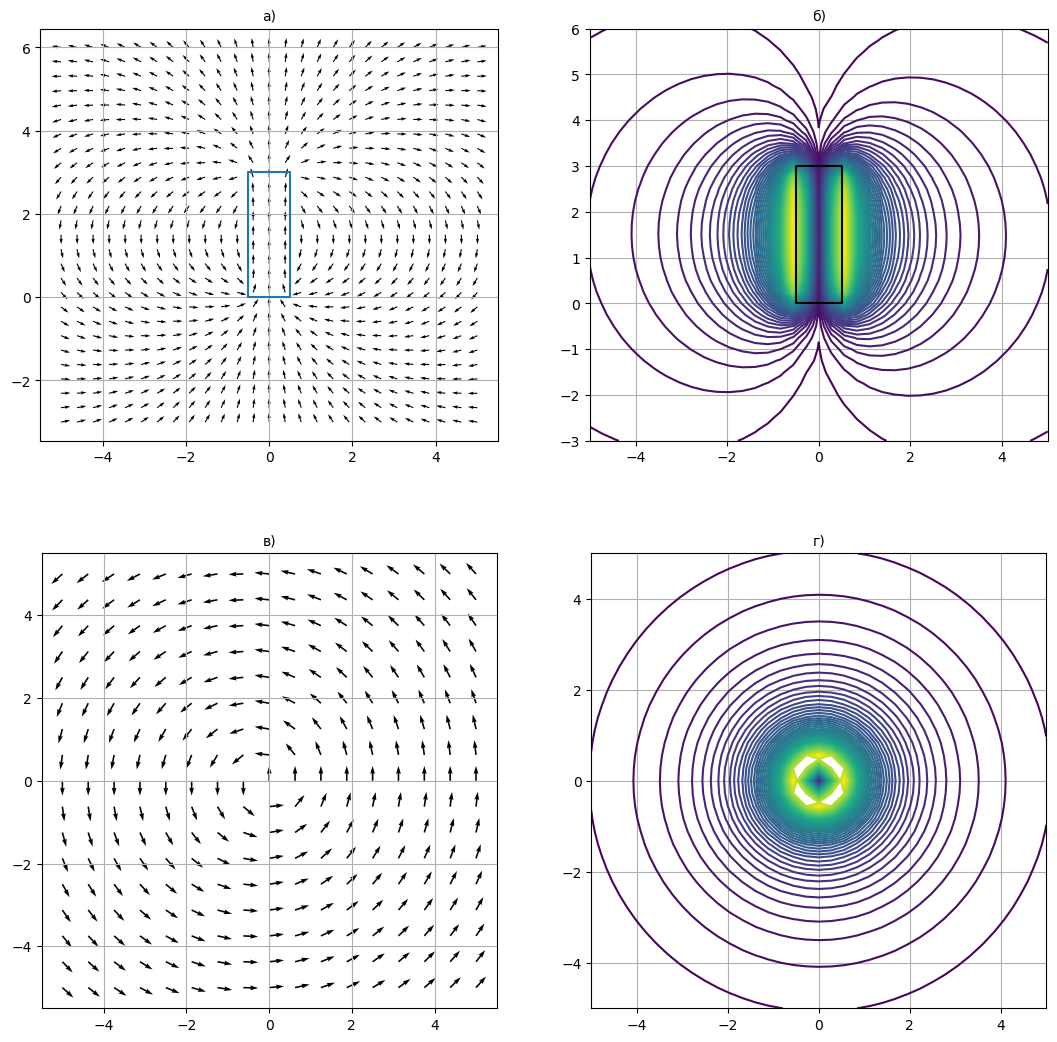

In [6]:
# Ячейка № 6

# визуализация силовых линий магнитного поля
# соленоида с постоянным током
# в плоскости YOZ

fig = plt.figure(figsize=(13, 13))

# визуализация поля единичных векторов,
# касательных к силовой линии магнитного поля,
# в узлах выбранной координатной сетки
ax = fig.add_subplot(2, 2, 1)
q = ax.quiver(Y1, Z1, by1, bz1)

ax.plot([-a, a, a, -a, -a], [0, 0, L, L, 0])
ax.set_aspect("equal", adjustable="box")
ax.set_title("а)", fontsize=10)
ax.grid(True)

ax = fig.add_subplot(2, 2, 2)
CS = ax.contour(Y2, Z2, A, levels=77)
ax.plot([-a, a, a, -a, -a], [0, 0, L, L, 0], color="black")
ax.set_aspect("equal", adjustable="box")
ax.set_title("б)", fontsize=10)
ax.grid(True)

ax = fig.add_subplot(2, 2, 3)
q = ax.quiver(X5, Y5, bx2_norm, by2_norm)
ax.set_aspect("equal", adjustable="box")
ax.set_title("в)", fontsize=10)
ax.grid(True)

ax = fig.add_subplot(2, 2, 4)
CS = ax.contour(X7, Y7, A2, levels=77)
ax.set_aspect("equal", adjustable="box")
ax.set_title("г)", fontsize=10)
ax.grid(True)


plt.show()

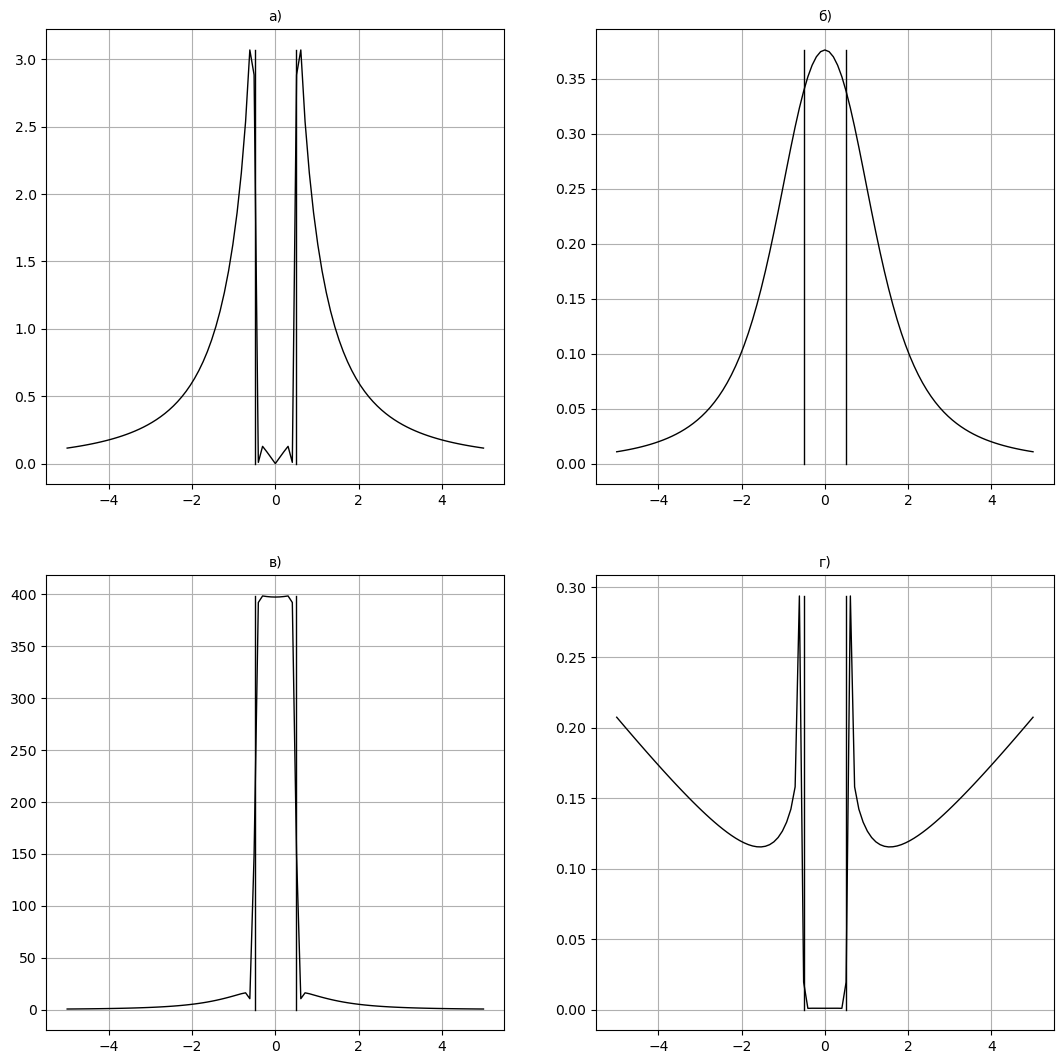

In [7]:
# Ячейка № 7

# вычисление и визуализация
# значений зависимостей
# Bx=Bx(x,y,1.5), By=By(x,y,1.5),
# Bz = Bz(x,y,1.5), B_otn=Bx/(By^2+Bz^2)

# задание числа узлов сетки по оси OY
Ny = 99

# задание значения координат по переменной y
Y = np.linspace(Ymin, Ymax, Ny)


# инициализация массивов Bx2, By2, Bz2, используемых для
# для хранения значений составляющих напряженности
# магнитного поля соленоида по осям OX,OY,OZ
Bx3 = np.zeros(Ny)
By3 = np.zeros(Ny)
Bz3 = np.zeros(Ny)
B3_otn = np.zeros(Ny)

# вычисление значений зависимостей
# Bx=Bx(x,y,1.5), By=By(x,y,1.5),
# Bz = Bz(x,y,1.5), B_otn=(Bx^2+By^2)^0.5/|Bz|
# в соответствие с (5.37)
for i in range(Ny):
    bx, by, bz = Solenoid(0, Y[i], 1.5, a, h, N)
    Bx3[i] = bx
    By3[i] = by
    Bz3[i] = bz
    B3_otn[i] = np.sqrt(bx**2 + by**2) / np.absolute(bz)

# визуализация зависимостей
# Bx=Bx(x,y,1.5), By=By(1.5,y,1.5),
# Bz = Bz(y,y,1.5), B_otn=(Bx^2+By^2)^0.5)/|Bz|

fig = plt.figure(figsize=(13, 13))

ax = fig.add_subplot(2, 2, 1)
ax.plot(Y, np.absolute(Bx3), "-k", lw=1)
ax.plot([-a, -a], [0, np.max(np.absolute(Bx3))], "-k", lw=1)
ax.plot([a, a], [0, np.max(np.absolute(Bx3))], "-k", lw=1)
ax.set_title("а)", fontsize=10)
ax.grid(True)

ax = fig.add_subplot(2, 2, 2)
ax.plot(Y, np.absolute(By3), "-k", lw=1)
ax.plot([-a, -a], [0, np.max(np.absolute(By3))], "-k", lw=1)
ax.plot([a, a], [0, np.max(np.absolute(By3))], "-k", lw=1)
ax.set_title("б)", fontsize=10)
ax.grid(True)

ax = fig.add_subplot(2, 2, 3)
ax.plot(Y, np.absolute(Bz3), "-k", lw=1)
ax.plot([-a, -a], [0, np.max(np.absolute(Bz3))], "-k", lw=1)
ax.plot([a, a], [0, np.max(np.absolute(Bz3))], "-k", lw=1)
ax.set_title("в)", fontsize=10)
ax.grid(True)

ax = fig.add_subplot(2, 2, 4)
ax.plot(Y, np.absolute(B3_otn), "-k", lw=1)
ax.plot([-a, -a], [0, np.max(np.absolute(B3_otn))], "-k", lw=1)
ax.plot([a, a], [0, np.max(np.absolute(B3_otn))], "-k", lw=1)
ax.set_title("г)", fontsize=10)
ax.grid(True)


plt.show()